# Controlador Fuzzy Mamdani Otimizado por Algoritmo Genetico

Rastreamento de trajetoria de robo autonomo (modelo bicicleta).

**Artigo base:** Mancilla et al., *"Optimal Fuzzy Controller Design for Autonomous Robot Path Tracking Using Population-Based Metaheuristics"*, Symmetry 2022, 14, 202.

---

## Estrutura do Notebook

| Secao | Descricao |
|---|---|
| 1 | Imports e parametros do modelo cinematico |
| 2 | Definicao das trajetorias de referencia (Pistas M, A, S) |
| 3 | Construcao do controlador Fuzzy parametrizavel |
| 4 | Simulacao cinematica (Euler discreto) |
| 5 | Algoritmo Genetico Real (AG) |
| 6 | **Parte 1** - Fuzzy Baseline (sem otimizacao) |
| 7 | **Parte 2** - Otimizacao Evolutiva (5 execucoes) |
| 8 | Resultados e comparacao final |

## 1. Imports e Parametros

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from scipy.spatial import cKDTree
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import os

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

os.makedirs('resultados', exist_ok=True)

# Parametros cinematicos (Tabela 6 do artigo)
L = 2.5            # wheelbase
V_R = 10.0 / 3.0   # velocidade alvo (~3.33 m/s)
DELTA_MAX = np.pi / 4
T_MAX, DT = 50.0, 0.1

print(f'Modelo cinematico: L={L}m, V_R={V_R:.2f}m/s, dt={DT}s, t_max={T_MAX}s')

Modelo cinematico: L=2.5m, V_R=3.33m/s, dt=0.1s, t_max=50.0s


## 2. Trajetorias de Referencia (Pistas M, A, S)

Pontos de controle interpolados via **Cubic Spline** conforme Tabela 4 do artigo.

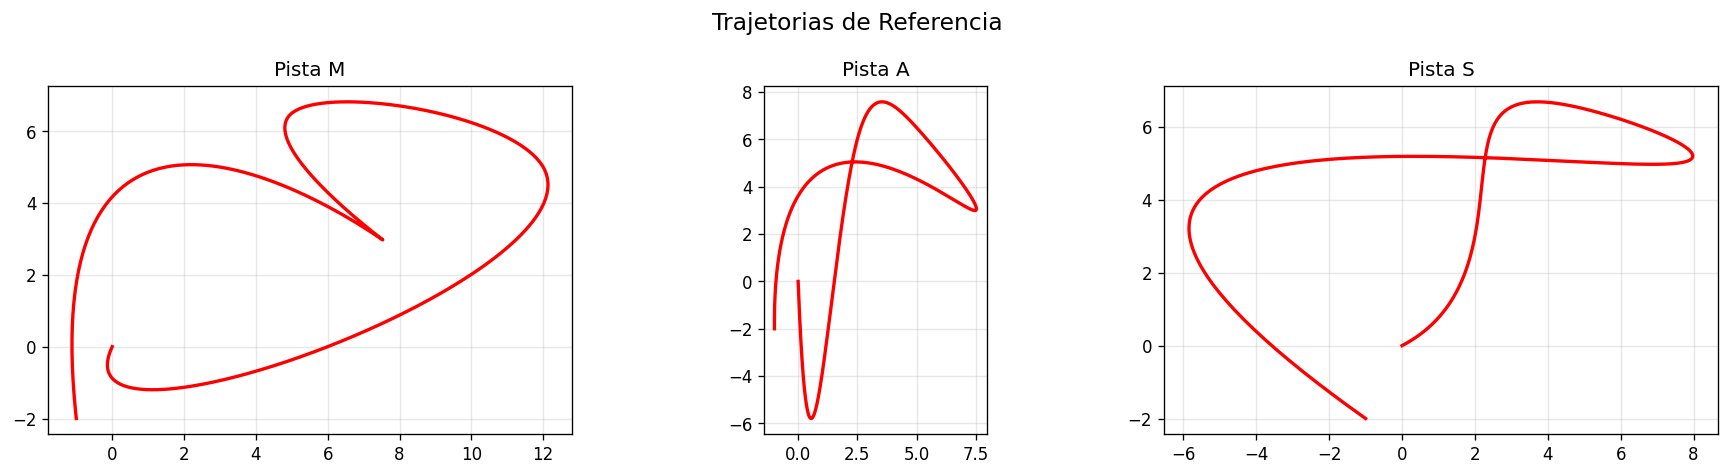

In [2]:
class Track:
    def __init__(self, name, ax, ay):
        self.name = name
        t = np.linspace(0, 1, len(ax))
        self.cs_x, self.cs_y = CubicSpline(t, ax), CubicSpline(t, ay)
        td = np.linspace(0, 1, 500)
        self.rx, self.ry = self.cs_x(td), self.cs_y(td)
        self.rdx, self.rdy = self.cs_x(td, 1), self.cs_y(td, 1)
        self.tree = cKDTree(np.column_stack([self.rx, self.ry]))

    def closest(self, x, y):
        _, idx = self.tree.query([x, y])
        return self.rx[idx], self.ry[idx], self.rdx[idx], self.rdy[idx], idx

TRACKS = [
    Track('M', [0,6,12,5,7.5,3,-1],   [0,0,5,6.5,3,5,-2]),
    Track('A', [0,1,2.5,5,7.5,3,-1],  [0,-4,6,6.5,3,5,-2]),
    Track('S', [0,2,2.5,5,7.5,-3,-1], [0,3,6,6.5,5,5,-2]),
]

# Visualizar as 3 pistas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, t in zip(axes, TRACKS):
    ax.plot(t.rx, t.ry, 'r-', lw=2)
    ax.set_title(f'Pista {t.name}')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
fig.suptitle('Trajetorias de Referencia', fontsize=14)
plt.tight_layout(); plt.show()

## 3. Controlador Fuzzy Parametrizavel

Base de **25 regras** (5x5) mapeadas na matriz abaixo. O vetor `params[0..9]` controla a forma das MFs de entrada.

| $\theta_e$ \\ $e$ | AN | MN | Z | MP | AP |
|:---:|:---:|:---:|:---:|:---:|:---:|
| **AN** | AP | AP | AP | MP | Z |
| **MN** | MP | MP | MP | MP | Z |
| **Z**  | AP | Z  | Z  | Z  | AN |
| **MP** | Z  | MN | MN | MN | MN |
| **AP** | Z  | MN | AN | AN | AN |

In [3]:
# Convencao de sinais (ver docs/base_de_regras.md):
#   e_lat   > 0 -> robo a DIREITA da trajetoria;  theta_e > 0 -> apontando a ESQUERDA.
#   omega   > 0 -> guinada anti-horaria (vira a esquerda).
# Linhas = theta_e (AN..AP); colunas = e_lat (AN..AP); valor = indice da MF de omega.
RULE_MATRIX = [
    [2, 3, 4, 4, 4],  # theta_e = AN (Z, MP, AP, AP, AP)
    [2, 3, 3, 3, 3],  # theta_e = MN (Z, MP, MP, MP, MP)
    [0, 2, 2, 2, 4],  # theta_e = Z  (AN, Z, Z, Z, AP)
    [1, 1, 1, 1, 2],  # theta_e = MP (MN, MN, MN, MN, Z)
    [0, 0, 0, 1, 2],  # theta_e = AP (AN, AN, AN, MN, Z)
]
LABELS = ['AN','MN','Z','MP','AP']

def build_fuzzy(params):
    """Mapeia vetor [0,1]^10 -> MFs parametrizadas (Tabela 2 do artigo)."""
    a, f = params[0], params[5]
    b, g = 0.5 + params[1]*1.5, 0.5 + params[6]*1.5
    c, h = params[2]*2.0, params[7]*2.0
    d, i = 0.5 + params[3], 0.5 + params[8]
    e, j = params[4], params[9]

    univ = np.arange(-50.0, 50.1, 0.1)  # resolucao 0.1 para plotagem
    te = ctrl.Antecedent(univ, 'theta_e')
    er = ctrl.Antecedent(univ, 'err')
    om = ctrl.Consequent(univ, 'omega')

    # MFs de theta_e (erro angular)
    te['AN'] = fuzz.trapmf(univ, [-50,-5,-b,-b+c])
    te['MN'] = fuzz.trimf(univ, [-d-e,-d,-d+e])
    te['Z']  = fuzz.trimf(univ, [-a,0,a])
    te['MP'] = fuzz.trimf(univ, [d-e,d,d+e])
    te['AP'] = fuzz.trapmf(univ, [b-c,b,5,50])

    # MFs de err (erro lateral)
    er['AN'] = fuzz.trapmf(univ, [-50,-5,-g,-g+h])
    er['MN'] = fuzz.trimf(univ, [-i-j,-i,-i+j])
    er['Z']  = fuzz.trimf(univ, [-f,0,f])
    er['MP'] = fuzz.trimf(univ, [i-j,i,i+j])
    er['AP'] = fuzz.trapmf(univ, [g-h,g,5,50])

    # MFs de omega (saida) - fixas
    om['AN'] = fuzz.trapmf(univ, [-50,-5,-1,-0.5])
    om['MN'] = fuzz.trimf(univ, [-1,-0.5,0])
    om['Z']  = fuzz.trimf(univ, [-0.5,0,0.5])
    om['MP'] = fuzz.trimf(univ, [0,0.5,1])
    om['AP'] = fuzz.trapmf(univ, [0.5,1,5,50])

    rules = []
    for r, te_label in enumerate(LABELS):
        for col, er_label in enumerate(LABELS):
            om_label = LABELS[RULE_MATRIX[r][col]]
            rules.append(ctrl.Rule(te[te_label] & er[er_label], om[om_label]))

    sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))
    return sim, te, er, om

print(f'Controlador: {len(LABELS)}x{len(LABELS)} = {len(LABELS)**2} regras')

# --- Motor de Inferencia Mamdani Otimizado em NumPy (~1500x mais rapido que skfuzzy) ---
def trimf(x, abc):
    a, b, c = abc
    if x <= a or x >= c: return 0.0
    if x == b: return 1.0
    if x < b: return (x - a) / (b - a)
    return (c - x) / (c - b)

def trapmf(x, abcd):
    a, b, c, d = abcd
    if x <= a or x >= d: return 0.0
    if b <= x <= c: return 1.0
    if x < b: return (x - a) / (b - a)
    return (d - x) / (d - c)

UNIV_FAST = np.arange(-50.0, 50.1, 1.0)
OM_MFS_FAST = [
    np.array([trapmf(x, [-50,-5,-1,-0.5]) for x in UNIV_FAST]),
    np.array([trimf(x, [-1,-0.5,0]) for x in UNIV_FAST]),
    np.array([trimf(x, [-0.5,0,0.5]) for x in UNIV_FAST]),
    np.array([trimf(x, [0,0.5,1]) for x in UNIV_FAST]),
    np.array([trapmf(x, [0.5,1,5,50]) for x in UNIV_FAST])
]

class FastFuzzyController:
    def __init__(self, params):
        self.a, self.f = params[0], params[5]
        self.b, self.g = 0.5 + params[1]*1.5, 0.5 + params[6]*1.5
        self.c, self.h = params[2]*2.0, params[7]*2.0
        self.d, self.i = 0.5 + params[3], 0.5 + params[8]
        self.e, self.j = params[4], params[9]

    def compute(self, err_val, te_val):
        te_deg = [
            trapmf(te_val, [-50, -5, -self.b, -self.b+self.c]),
            trimf(te_val, [-self.d-self.e, -self.d, -self.d+self.e]),
            trimf(te_val, [-self.a, 0, self.a]),
            trimf(te_val, [self.d-self.e, self.d, self.d+self.e]),
            trapmf(te_val, [self.b-self.c, self.b, 5, 50])
        ]
        er_deg = [
            trapmf(err_val, [-50, -5, -self.g, -self.g+self.h]),
            trimf(err_val, [-self.i-self.j, -self.i, -self.i+self.j]),
            trimf(err_val, [-self.f, 0, self.f]),
            trimf(err_val, [self.i-self.j, self.i, self.i+self.j]),
            trapmf(err_val, [self.g-self.h, self.g, 5, 50])
        ]

        om_deg = [0.0]*5
        for r in range(5):
            for col in range(5):
                act = min(te_deg[r], er_deg[col])
                out_mf = RULE_MATRIX[r][col]
                if act > om_deg[out_mf]:
                    om_deg[out_mf] = act

        aggregated = np.zeros_like(UNIV_FAST)
        for idx in range(5):
            if om_deg[idx] > 0:
                aggregated = np.maximum(aggregated, np.minimum(om_deg[idx], OM_MFS_FAST[idx]))

        sum_agg = np.sum(aggregated)
        if sum_agg == 0:
            raise Exception("No rules")
        return np.sum(UNIV_FAST * aggregated) / sum_agg


Controlador: 5x5 = 25 regras


## 4. Simulacao Cinematica e Fitness

In [4]:
def simulate(controller, track):
    """Simula ate o robo alcancar o fim da pista ou estourar T_MAX.
    Penaliza em +2000 controladores que nao completam o percurso."""
    xr, yr, th = 0.0, 0.0, 0.0
    hx, hy, ssq = [], [], 0.0
    steps = int(T_MAX / DT)
    last_idx = len(track.rx) - 1
    n_exec, reached = 0, False

    for _ in range(steps):
        hx.append(xr); hy.append(yr)
        rx, ry, rdx, rdy, idx = track.closest(xr, yr)

        # Erro lateral (produto vetorial) e angular
        n = np.hypot(rdx, rdy) + 1e-6
        e_lat = (xr-rx)*rdy/n - (yr-ry)*rdx/n
        e_ang = ((th - np.arctan2(rdy, rdx)) + np.pi) % (2*np.pi) - np.pi

        try:
            w = controller.compute(np.clip(e_lat, -49.99, 49.99), np.clip(e_ang, -49.99, 49.99))
        except Exception:
            return 5000.0, hx, hy  # penalidade

        delta = np.clip(np.arctan(L*w/V_R), -DELTA_MAX, DELTA_MAX)
        xr += V_R * np.cos(th) * DT
        yr += V_R * np.sin(th) * DT
        th += (V_R/L) * np.tan(delta) * DT
        ssq += e_lat**2
        n_exec += 1

        # criterio de chegada: abeam dos ultimos pontos da pista e perto do fim
        if idx >= last_idx - 2 and np.hypot(xr - track.rx[-1], yr - track.ry[-1]) < 2.0:
            reached = True
            break

    rmse = np.sqrt(ssq / n_exec)
    if not reached:
        rmse += 2000.0
    return rmse, hx, hy

def fitness(params):
    """RMSE medio nas 3 pistas (Eq. 12 do artigo)."""
    controller = FastFuzzyController(params)
    return np.mean([simulate(controller, t)[0] for t in TRACKS])

print('Funcoes de simulacao e fitness definidas.')


Funcoes de simulacao e fitness definidas.


## 5. Algoritmo Genetico Real

In [5]:
def run_ga(pop_size=30, gens=20, pc=0.7, pm=0.3, sigma=0.2):
    """AG com elitismo, torneio k=3, cruzamento aritmetico e mutacao gaussiana."""
    pop = np.random.rand(pop_size, 10)
    fit = np.array([fitness(ind) for ind in pop])
    best_i = np.argmin(fit)
    gbest, gbest_f = pop[best_i].copy(), fit[best_i]
    hist = [gbest_f]
    print(f'  Gen 0 | Best: {gbest_f:.4f}')

    for g in range(1, gens+1):
        new = list(pop[np.argsort(fit)[:2]])  # elitismo (2)
        while len(new) < pop_size:
            p1 = pop[min(np.random.choice(pop_size, 3, replace=False), key=lambda x: fit[x])]
            p2 = pop[min(np.random.choice(pop_size, 3, replace=False), key=lambda x: fit[x])]
            if np.random.rand() < pc:
                al = np.random.rand(10)
                c1, c2 = al*p1 + (1-al)*p2, al*p2 + (1-al)*p1
            else:
                c1, c2 = p1.copy(), p2.copy()
            for c in (c1, c2):
                m = np.random.rand(10) < pm
                c[m] += np.random.normal(0, sigma, m.sum())
                np.clip(c, 0, 1, out=c)
                if len(new) < pop_size:
                    new.append(c)
        pop = np.array(new)
        fit = np.array([fitness(ind) for ind in pop])
        bi = np.argmin(fit)
        if fit[bi] < gbest_f:
            gbest, gbest_f = pop[bi].copy(), fit[bi]
        print(f'  Gen {g} | Best: {gbest_f:.4f} | Mean: {np.mean(fit):.4f}')
        hist.append(gbest_f)
    return gbest, gbest_f, hist

print('AG definido: elitismo=2, torneio k=3, cruzamento aritmetico, mutacao gaussiana.')

AG definido: elitismo=2, torneio k=3, cruzamento aritmetico, mutacao gaussiana.


---

## 6. PARTE 1 - Fuzzy Baseline (Sem Otimizacao)

Parametros iniciais fixos em `0.5` (centro do dominio `[0,1]`). Servem como **linha de base** para comparacao.

In [6]:
base_params = np.full(10, 0.5)
base_controller = FastFuzzyController(base_params)
fsim_base, te_base, er_base, om_base = build_fuzzy(base_params)
base_rmse = fitness(base_params)
print(f'RMSE medio baseline: {base_rmse:.4f}')

RMSE medio baseline: 1.5601


### 6.1 Trajetorias do Fuzzy Baseline

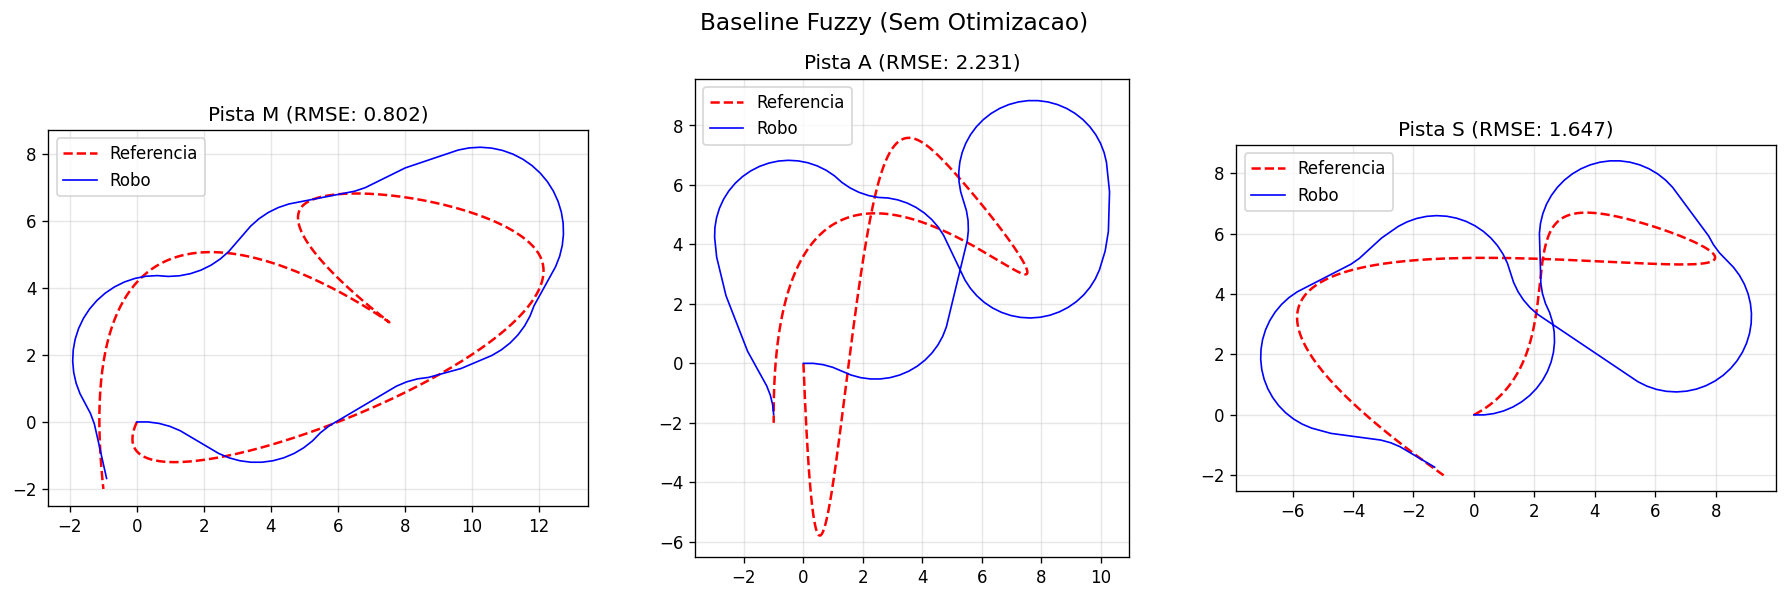

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, track in zip(axes, TRACKS):
    rmse, hx, hy = simulate(base_controller, track)
    ax.plot(track.rx, track.ry, 'r--', lw=1.5, label='Referencia')
    ax.plot(hx, hy, 'b-', lw=1, label='Robo')
    ax.set_title(f'Pista {track.name} (RMSE: {rmse:.3f})')
    ax.legend(); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
fig.suptitle('Baseline Fuzzy (Sem Otimizacao)', fontsize=14)
plt.tight_layout()
fig.savefig('resultados/baseline_trajectories.png', dpi=150)
plt.show()

### 6.2 MFs do Baseline

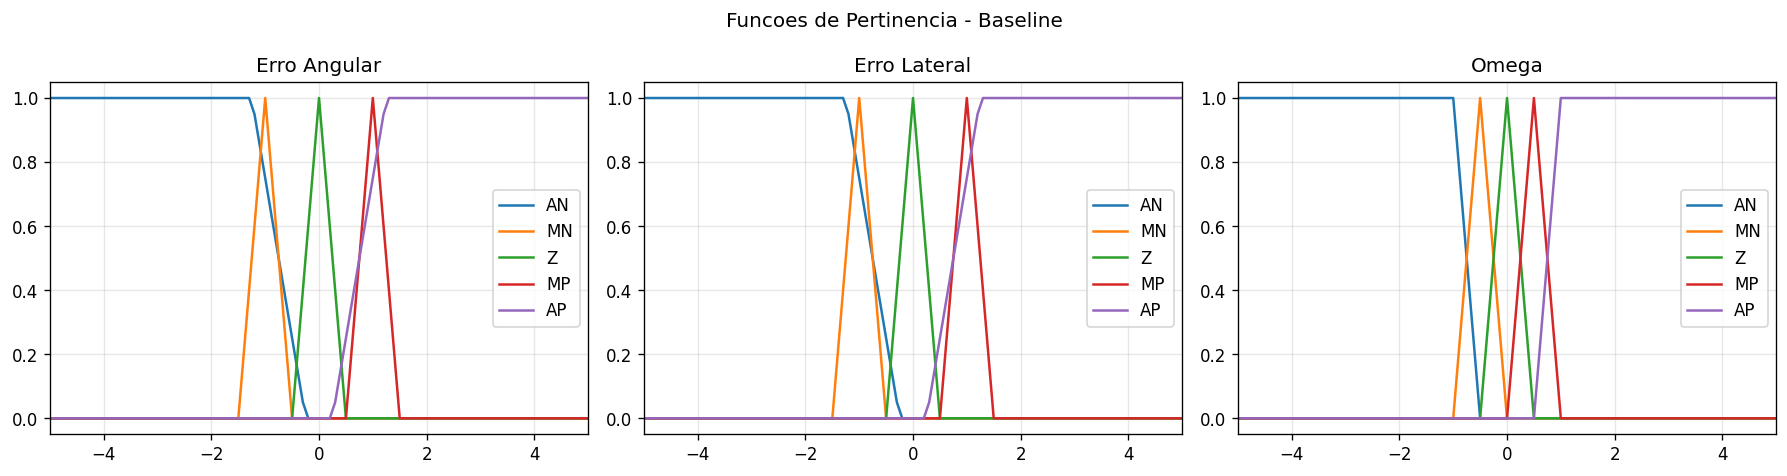

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var, name in zip(axes, [te_base, er_base, om_base], ['Erro Angular', 'Erro Lateral', 'Omega']):
    for label in LABELS:
        ax.plot(var.universe, var[label].mf, label=label)
    ax.set_title(name); ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 5)  # zoom na regiao ativa
fig.suptitle('Funcoes de Pertinencia - Baseline')
plt.tight_layout(); plt.show()

### 6.3 Cenarios de Teste (6 cenarios exigidos pela rubrica)

In [9]:
def eval_scenarios(fsim, label):
    scenarios = [
        (0.0, 0.0, 'Centro, alinhado (caso nulo)'),
        (5.0, 0.0, 'Direita, alinhado (erro lateral alto)'),
        (-5.0, 0.0, 'Esquerda, alinhado (erro lateral alto)'),
        (0.0, 2.0, 'Centro, apontando a esquerda (erro angular alto)'),
        (5.0, 2.0, 'Direita, apontando a esquerda (aproximacao)'),
        (-5.0, 2.0, 'Esquerda, apontando a esquerda (conflito critico)'),
    ]
    print(f"  {'Cenario':<50} | {label+' (omega)':>20}")
    print('  ' + '-'*75)
    for e_val, th_val, desc in scenarios:
        fsim.input['err'], fsim.input['theta_e'] = e_val, th_val
        try:
            fsim.compute()
            out = fsim.output['omega']
        except Exception:
            out = float('nan')
        print(f'  {desc:<50} | {out:>20.4f}')

print('Cenarios de teste - Baseline:')
eval_scenarios(fsim_base, 'Baseline')

Cenarios de teste - Baseline:
  Cenario                                            |     Baseline (omega)
  ---------------------------------------------------------------------------
  Centro, alinhado (caso nulo)                       |               0.0000
  Direita, alinhado (erro lateral alto)              |              17.2788
  Esquerda, alinhado (erro lateral alto)             |             -17.2788
  Centro, apontando a esquerda (erro angular alto)   |             -17.2788
  Direita, apontando a esquerda (aproximacao)        |               0.0000
  Esquerda, apontando a esquerda (conflito critico)  |             -17.2788


---

## 7. PARTE 2 - Otimizacao Evolutiva (AG)

5 execucoes independentes com sementes distintas (42 a 46), para dar robustez estatistica a analise do AG.

> **Nota:** Esta celula pode levar alguns minutos para executar.

In [10]:
best_ind, best_fit = None, float('inf')
histories = []

for run in range(5):
    seed = 42 + run
    np.random.seed(seed)
    print(f'\n--- Execucao {run+1}/5 (seed={seed}) ---')
    ind, fit, hist = run_ga(pop_size=20, gens=10)
    histories.append(hist)
    if fit < best_fit:
        best_fit, best_ind = fit, ind

print(f'\nMelhor RMSE global: {best_fit:.4f}')
print(f'Parametros otimizados: {np.round(best_ind, 3)}')


--- Execucao 1/5 (seed=42) ---


  Gen 0 | Best: 1.4007


  Gen 1 | Best: 1.4007 | Mean: 1484.4245


  Gen 2 | Best: 1.3437 | Mean: 318.0288


  Gen 3 | Best: 1.3437 | Mean: 601.2919


...

  Gen 6 | Best: 1.3236 | Mean: 1034.4398


  Gen 7 | Best: 1.3236 | Mean: 534.5967


  Gen 8 | Best: 1.3236 | Mean: 201.3650


  Gen 9 | Best: 1.3236 | Mean: 1201.0592


  Gen 10 | Best: 1.3193 | Mean: 34.7489

Melhor RMSE global: 1.2319
Parametros otimizados: [0.826 0.19  0.827 0.844 0.655 0.642 0.662 0.756 0.563 0.255]


### 7.1 Curvas de Convergencia

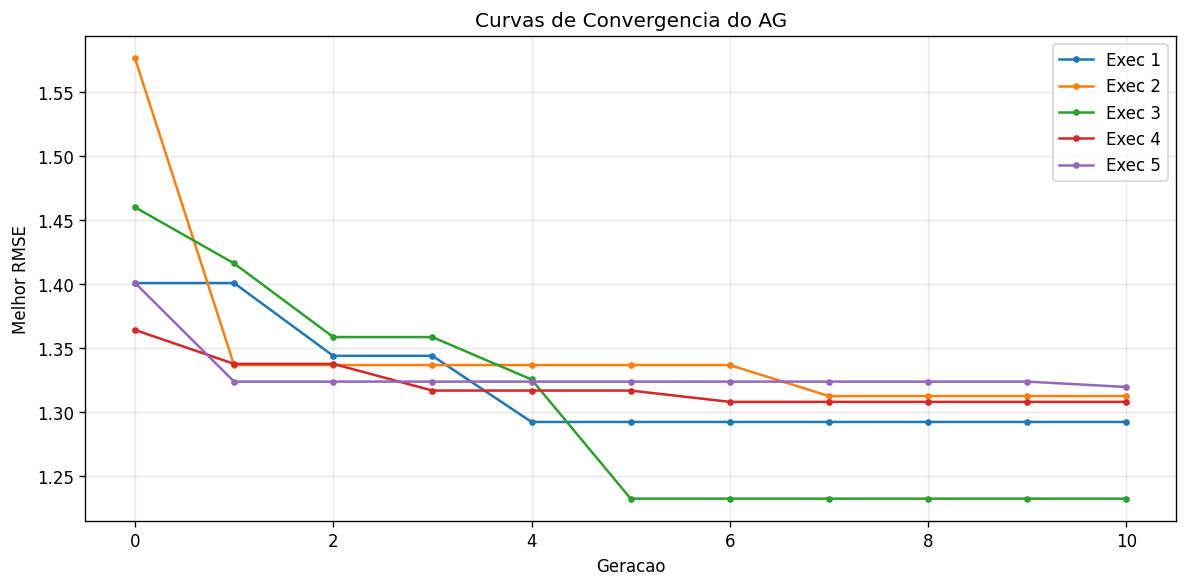

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
for i, h in enumerate(histories):
    ax.plot(h, marker='o', ms=3, label=f'Exec {i+1}')
ax.set(title='Curvas de Convergencia do AG', xlabel='Geracao', ylabel='Melhor RMSE')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('resultados/ag_convergence.png', dpi=150)
plt.show()

---

## 8. Resultados e Comparacao Final

### 8.1 Trajetorias do Fuzzy Otimizado

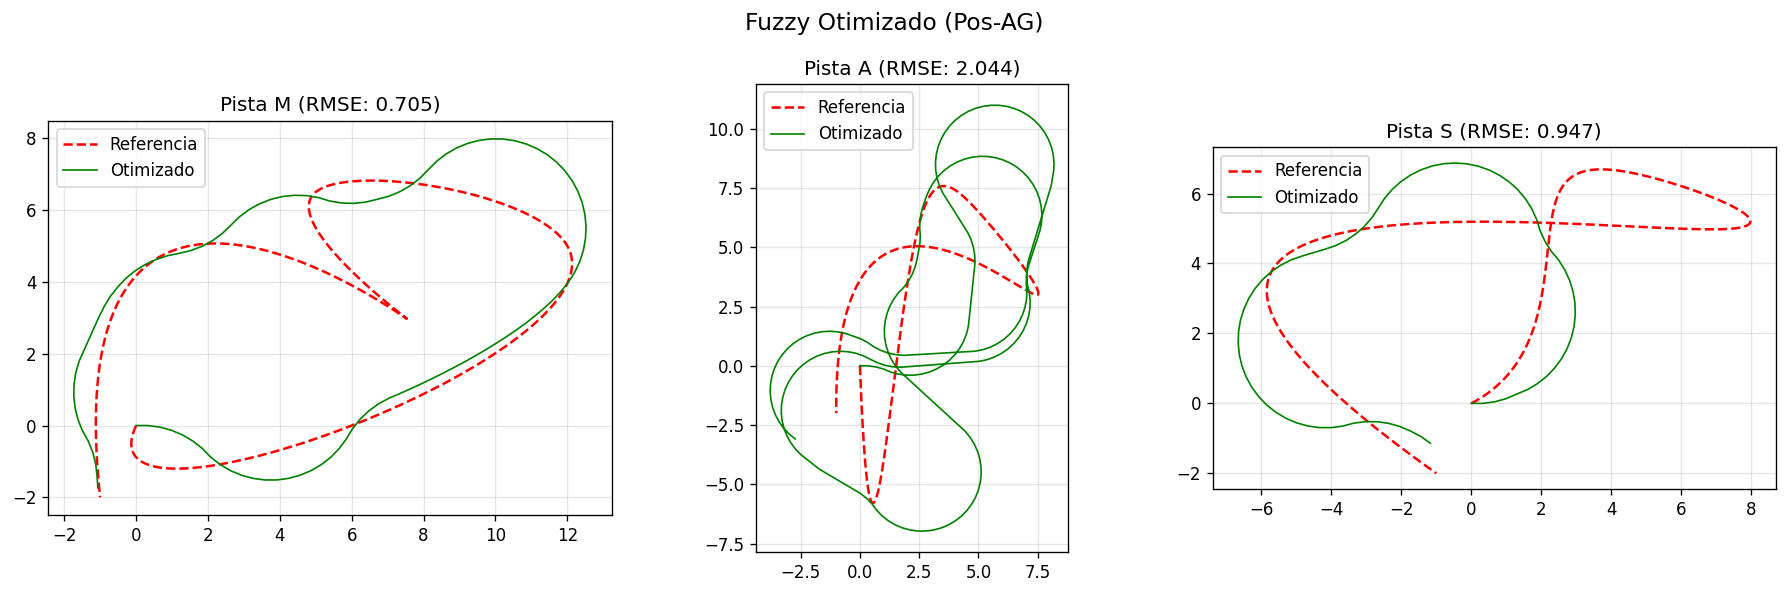

In [12]:
opt_controller = FastFuzzyController(best_ind)
fsim_opt, te_opt, er_opt, om_opt = build_fuzzy(best_ind)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, track in zip(axes, TRACKS):
    rmse, hx, hy = simulate(opt_controller, track)
    ax.plot(track.rx, track.ry, 'r--', lw=1.5, label='Referencia')
    ax.plot(hx, hy, 'g-', lw=1, label='Otimizado')
    ax.set_title(f'Pista {track.name} (RMSE: {rmse:.3f})')
    ax.legend(); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
fig.suptitle('Fuzzy Otimizado (Pos-AG)', fontsize=14)
plt.tight_layout()
fig.savefig('resultados/optimized_trajectories.png', dpi=150)
plt.show()


### 8.2 MFs Otimizadas

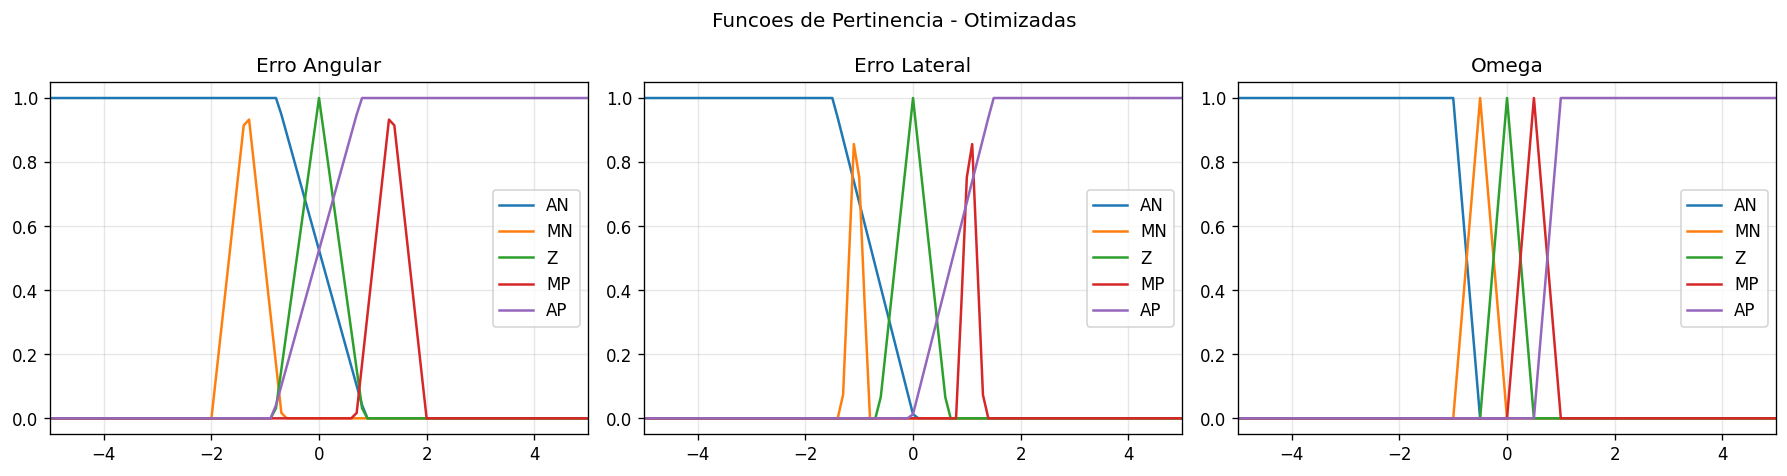

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var, name in zip(axes, [te_opt, er_opt, om_opt], ['Erro Angular', 'Erro Lateral', 'Omega']):
    for label in LABELS:
        ax.plot(var.universe, var[label].mf, label=label)
    ax.set_title(name); ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 5)
fig.suptitle('Funcoes de Pertinencia - Otimizadas')
plt.tight_layout()
fig.savefig('resultados/mfs_otimizadas.png', dpi=150)
plt.show()

### 8.3 Superficie de Controle

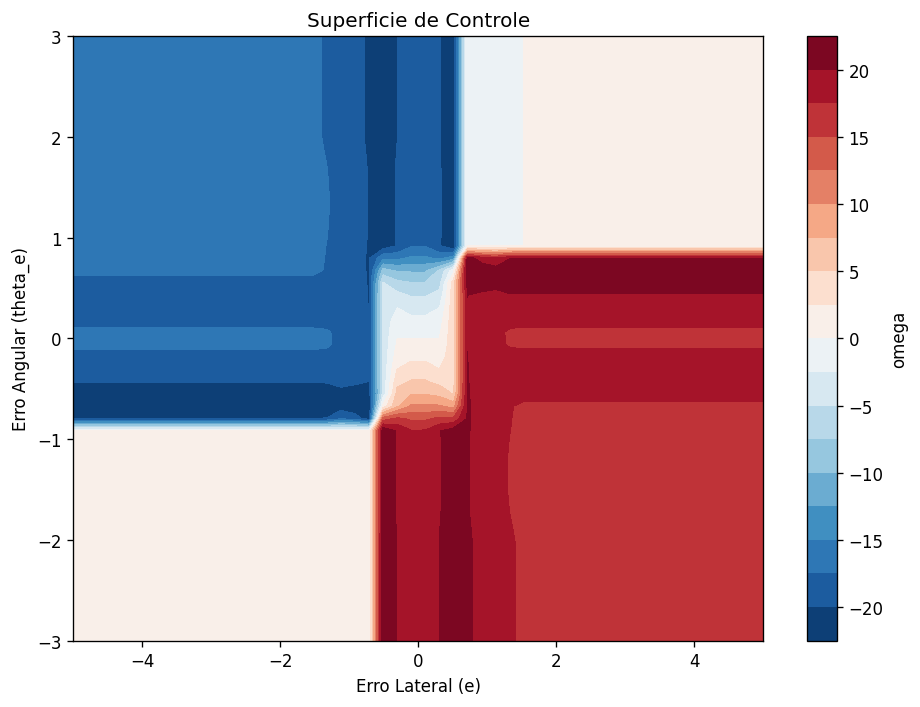

In [14]:
n = 50
e_range = np.linspace(-5, 5, n)
t_range = np.linspace(-3, 3, n)
Z = np.zeros((n, n))
for i, ev in enumerate(e_range):
    for j, tv in enumerate(t_range):
        fsim_opt.input['err'], fsim_opt.input['theta_e'] = ev, tv
        try:
            fsim_opt.compute()
            Z[j, i] = fsim_opt.output['omega']
        except Exception:
            Z[j, i] = 0

fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contourf(e_range, t_range, Z, levels=20, cmap='RdBu_r')
fig.colorbar(cs, ax=ax, label='omega')
ax.set(title='Superficie de Controle', xlabel='Erro Lateral (e)', ylabel='Erro Angular (theta_e)')
plt.tight_layout()
fig.savefig('resultados/superficie_controle.png', dpi=150)
plt.show()

### 8.4 Cenarios de Teste - Otimizado

In [15]:
print('Cenarios de teste - Otimizado:')
eval_scenarios(fsim_opt, 'Otimizado')

Cenarios de teste - Otimizado:
  Cenario                                            |    Otimizado (omega)
  ---------------------------------------------------------------------------
  Centro, alinhado (caso nulo)                       |               0.0000
  Direita, alinhado (erro lateral alto)              |              17.0322
  Esquerda, alinhado (erro lateral alto)             |             -17.0322
  Centro, apontando a esquerda (erro angular alto)   |             -17.2707
  Direita, apontando a esquerda (aproximacao)        |               0.0000
  Esquerda, apontando a esquerda (conflito critico)  |             -17.2788


### 8.5 Comparacao Numerica

In [16]:
opt_rmse = fitness(best_ind)

print('=' * 50)
print('COMPARACAO FINAL')
print('=' * 50)
print(f'  Baseline RMSE:   {base_rmse:.4f}')
print(f'  Otimizado RMSE:  {opt_rmse:.4f}')
print(f'  Melhoria:        {(1 - opt_rmse/base_rmse)*100:.1f}%')
print(f'\nGraficos salvos em ./resultados/')

COMPARACAO FINAL
  Baseline RMSE:   1.5601
  Otimizado RMSE:  1.2319
  Melhoria:        21.0%

Graficos salvos em ./resultados/
